In [1]:
from matplotlib.pyplot import *
import matplotlib.font_manager as fm

rcParams['mathtext.rm'] = "Arial"
rcParams['font.family'] = 'Arial'
for f in fm.findSystemFonts(fontpaths=None, fontext='ttf'):
    if 'arial' in f.lower():
        print(f)

C:\Windows\Fonts\arialbd.ttf
C:\Windows\Fonts\ariali.ttf
C:\Windows\Fonts\arial.ttf
C:\Windows\Fonts\arialbi.ttf


In [2]:
from select_points import load_data
path1 = "training_data/for_model1.csv"
path2 = "training_data/for_model2.csv"
X1, Y1 = load_data(path1)
X2, Y2 = load_data(path2)

In [4]:
from train_evaluation import normalize_data, train_LSmodels, train_RFmodels
norm_X1 = normalize_data(X1)
norm_X2 = normalize_data(X2)
LS_model1, all_LSperformance1 = train_LSmodels(norm_X1, Y1)
LS_model2, all_LSperformance2 = train_LSmodels(norm_X2, Y2)
RF_model1, all_RFperformance1, feature_importance1 = train_RFmodels(norm_X1, Y1)
RF_model2, all_RFperformance2, feature_importance2= train_RFmodels(norm_X2, Y2)

Training LabelSpreading with random_state=42
Training LabelSpreading with random_state=43
Training LabelSpreading with random_state=44
Training LabelSpreading with random_state=45
Training LabelSpreading with random_state=46
Training LabelSpreading with random_state=47
Training LabelSpreading with random_state=48
Training LabelSpreading with random_state=49
Training LabelSpreading with random_state=50
Training LabelSpreading with random_state=51
Training LabelSpreading with random_state=52
Training LabelSpreading with random_state=53
Training LabelSpreading with random_state=54
Training LabelSpreading with random_state=55
Training LabelSpreading with random_state=56
Training LabelSpreading with random_state=57
最佳模型验证集准确率: 0.7750
Training LabelSpreading with random_state=42
Training LabelSpreading with random_state=43
Training LabelSpreading with random_state=44
Training LabelSpreading with random_state=45
Training LabelSpreading with random_state=46
Training LabelSpreading with random_

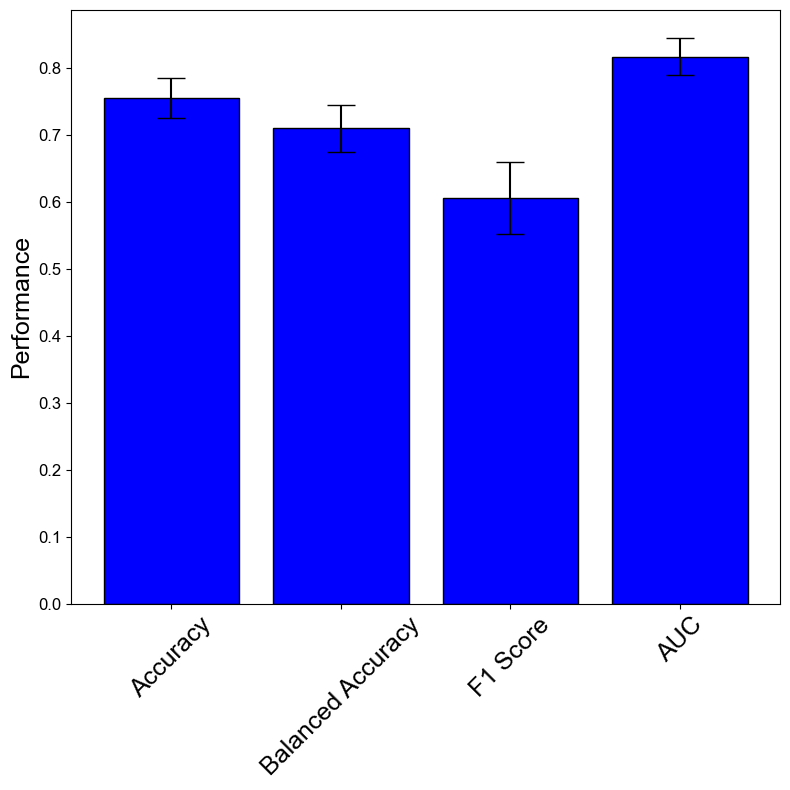

[0.755625   0.71052878 0.60600697 0.81730977]
[0.02999349 0.03484676 0.05388557 0.0277987 ]


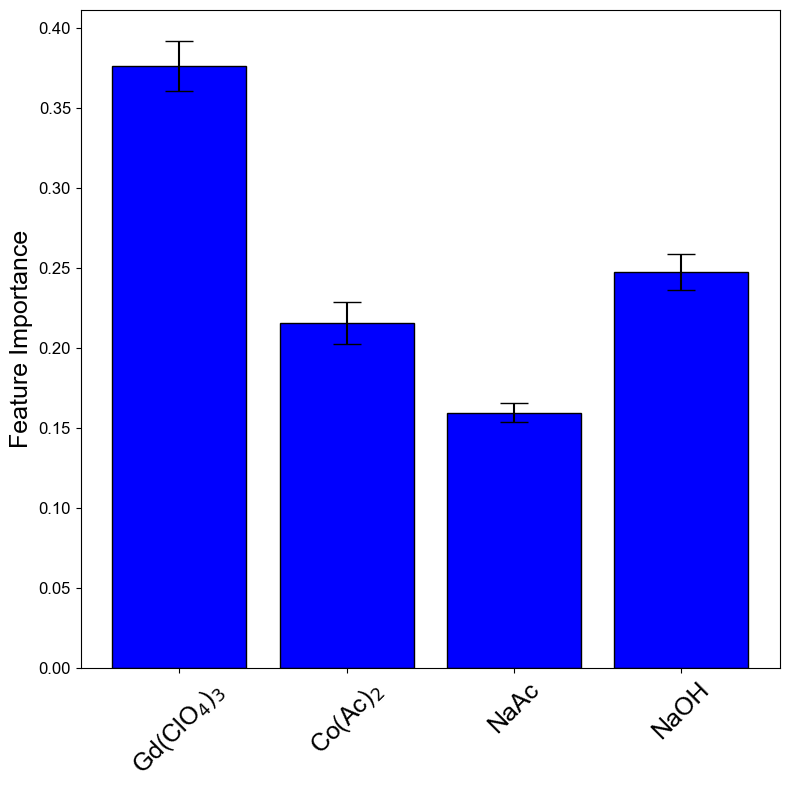

[0.37641956 0.21602686 0.15991882 0.24763477]
[0.01553114 0.01315425 0.00595748 0.01117849]


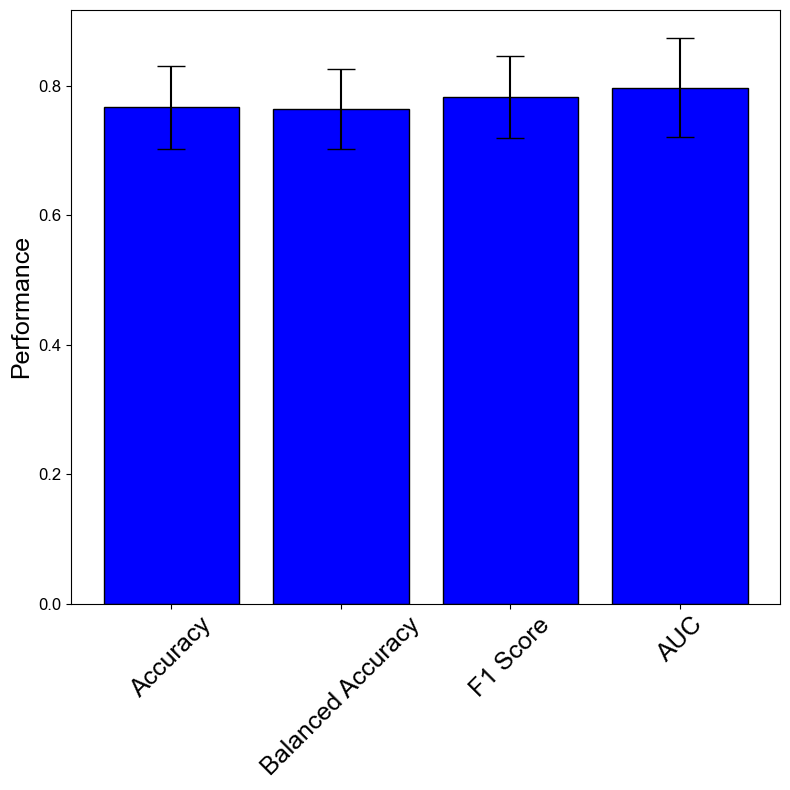

[0.76704545 0.76498668 0.78251043 0.79740635]
[0.06403084 0.06167128 0.06313843 0.07628382]


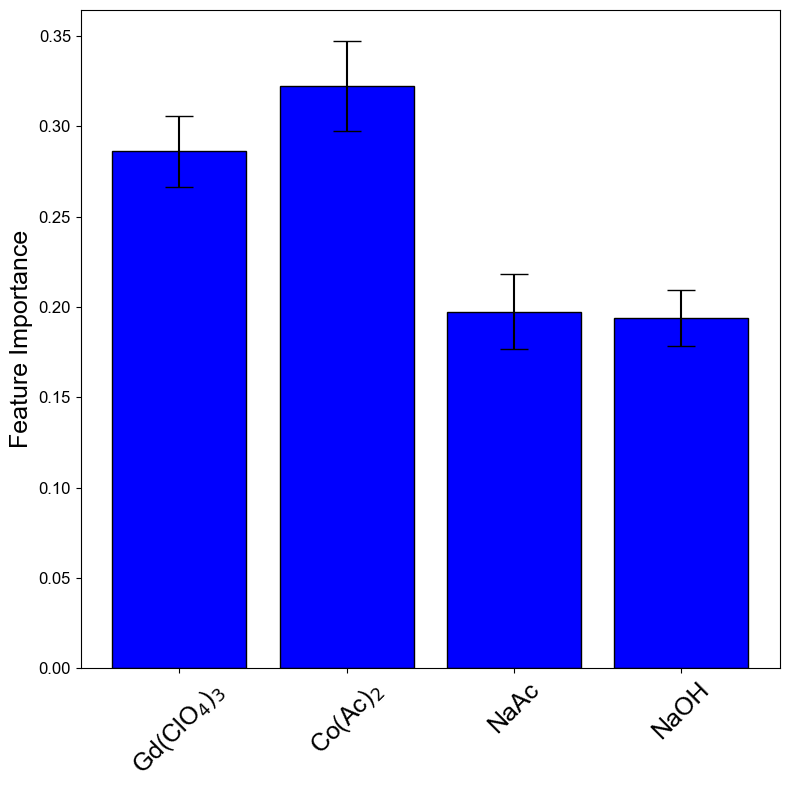

[0.28629315 0.32228493 0.19750959 0.19391232]
[0.01962308 0.02481548 0.02066295 0.01533878]


(array([0.28629315, 0.32228493, 0.19750959, 0.19391232]),
 array([0.01962308, 0.02481548, 0.02066295, 0.01533878]))

In [5]:
from plot_tools import plot_performance, plot_feature_importance
all_RFperformance1 = np.array(all_RFperformance1)
all_RFperformance2 = np.array(all_RFperformance2)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
plot_performance(all_RFperformance1)
plot_feature_importance(feature_importance1, feature_names)
plot_performance(all_RFperformance2)
plot_feature_importance(feature_importance2, feature_names)

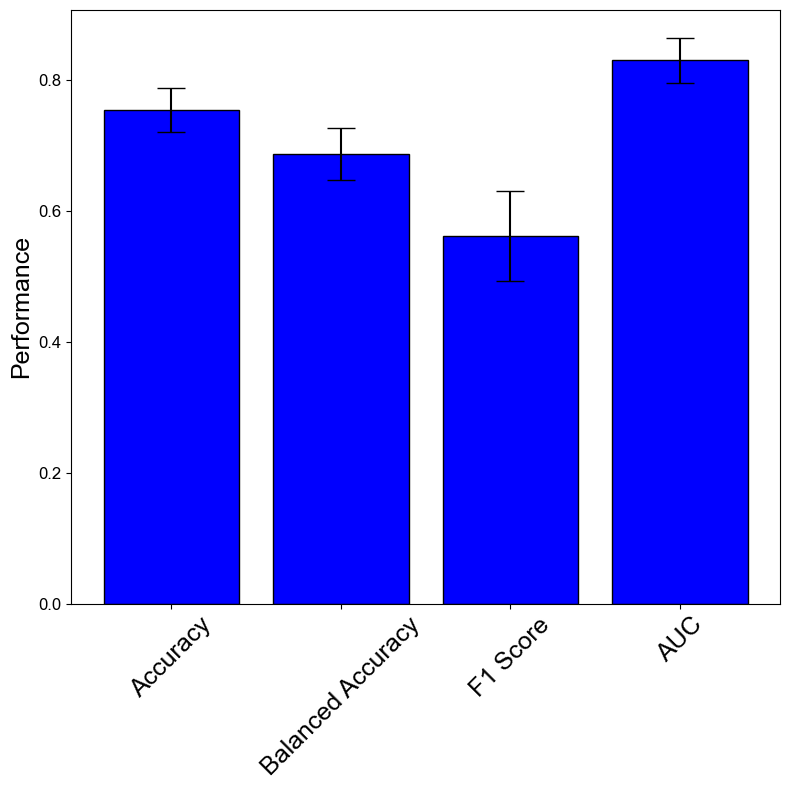

[0.75375    0.6864309  0.5612675  0.82930741]
[0.03314268 0.03928287 0.06894916 0.03377358]


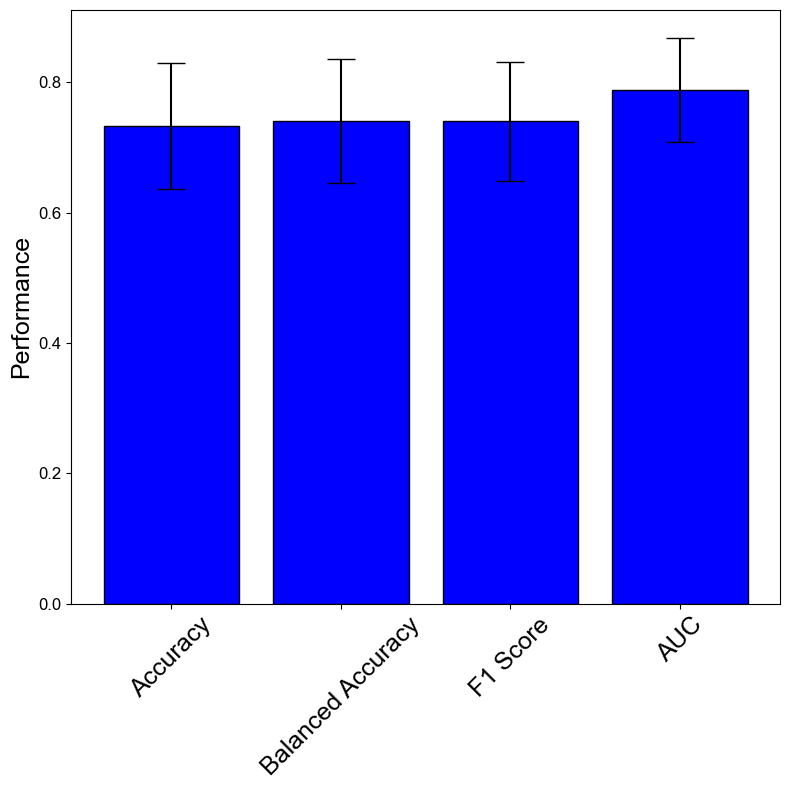

[0.73295455 0.74082911 0.73983929 0.78753861]
[0.09655377 0.09540637 0.09090415 0.0798802 ]


(array([0.73295455, 0.74082911, 0.73983929, 0.78753861]),
 array([0.09655377, 0.09540637, 0.09090415, 0.0798802 ]))

In [6]:
from plot_tools import plot_performance
all_LSperformance1 = np.array(all_LSperformance1)
all_LSperformance2 = np.array(all_LSperformance2)
plot_performance(all_LSperformance1)
plot_performance(all_LSperformance2)

(<Figure size 2400x2400 with 2 Axes>,
 <Axes: xlabel='Gd(ClO$_4$)$_3$', ylabel='NaOH'>)

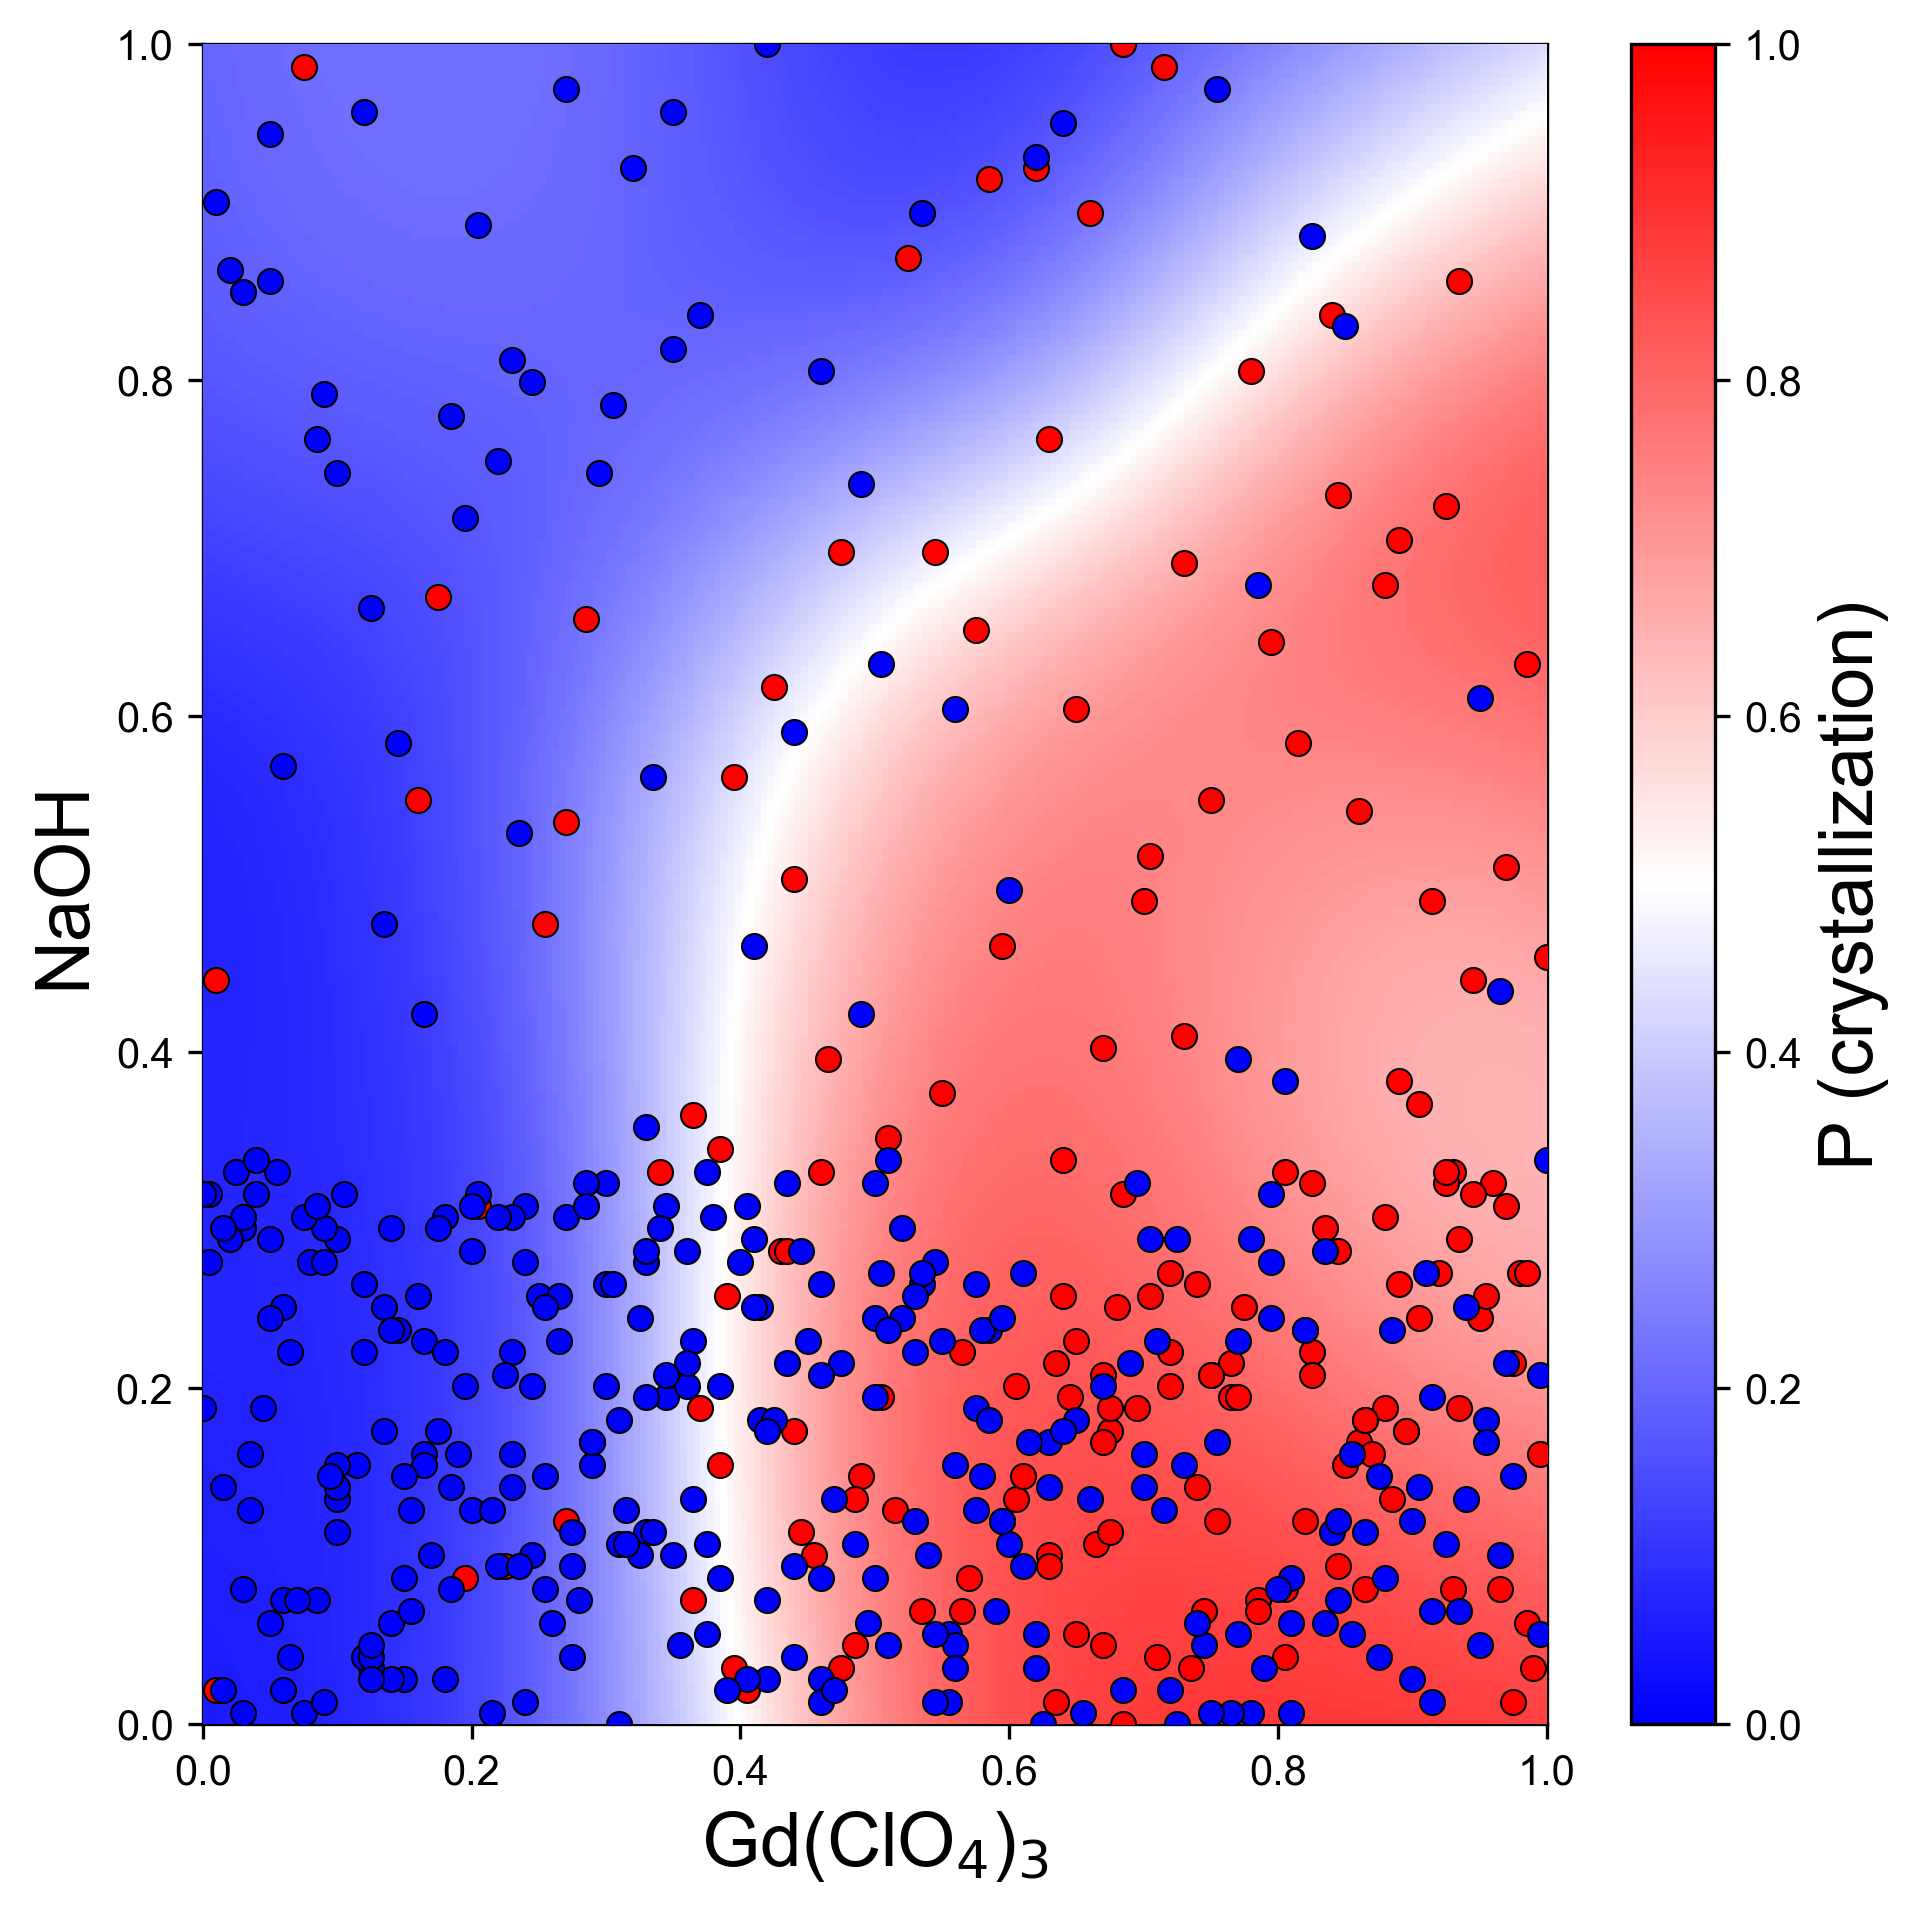

In [12]:
from plot_tools import plot_phase_diagram, create_prediction_grid
dimension_index = [0, 3]  # 选择要绘制的两个自由维度索引
X_grid, grid_shape = create_prediction_grid(
    fixed_dims=[1, 2], #选择固定的特征索引
    fixed_vals=[0.75, 0.5], #固定特征的值（选定切片位置）
    resolution=200  # 200^2 = 40000个点
)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
#做切片
plot_phase_diagram(LS_model1, X_grid, grid_shape, norm_X1, Y1, dimension_index, feature_names)


(<Figure size 2400x2400 with 2 Axes>,
 <Axes: xlabel='Gd(ClO$_4$)$_3$', ylabel='Co(Ac)$_2$'>)

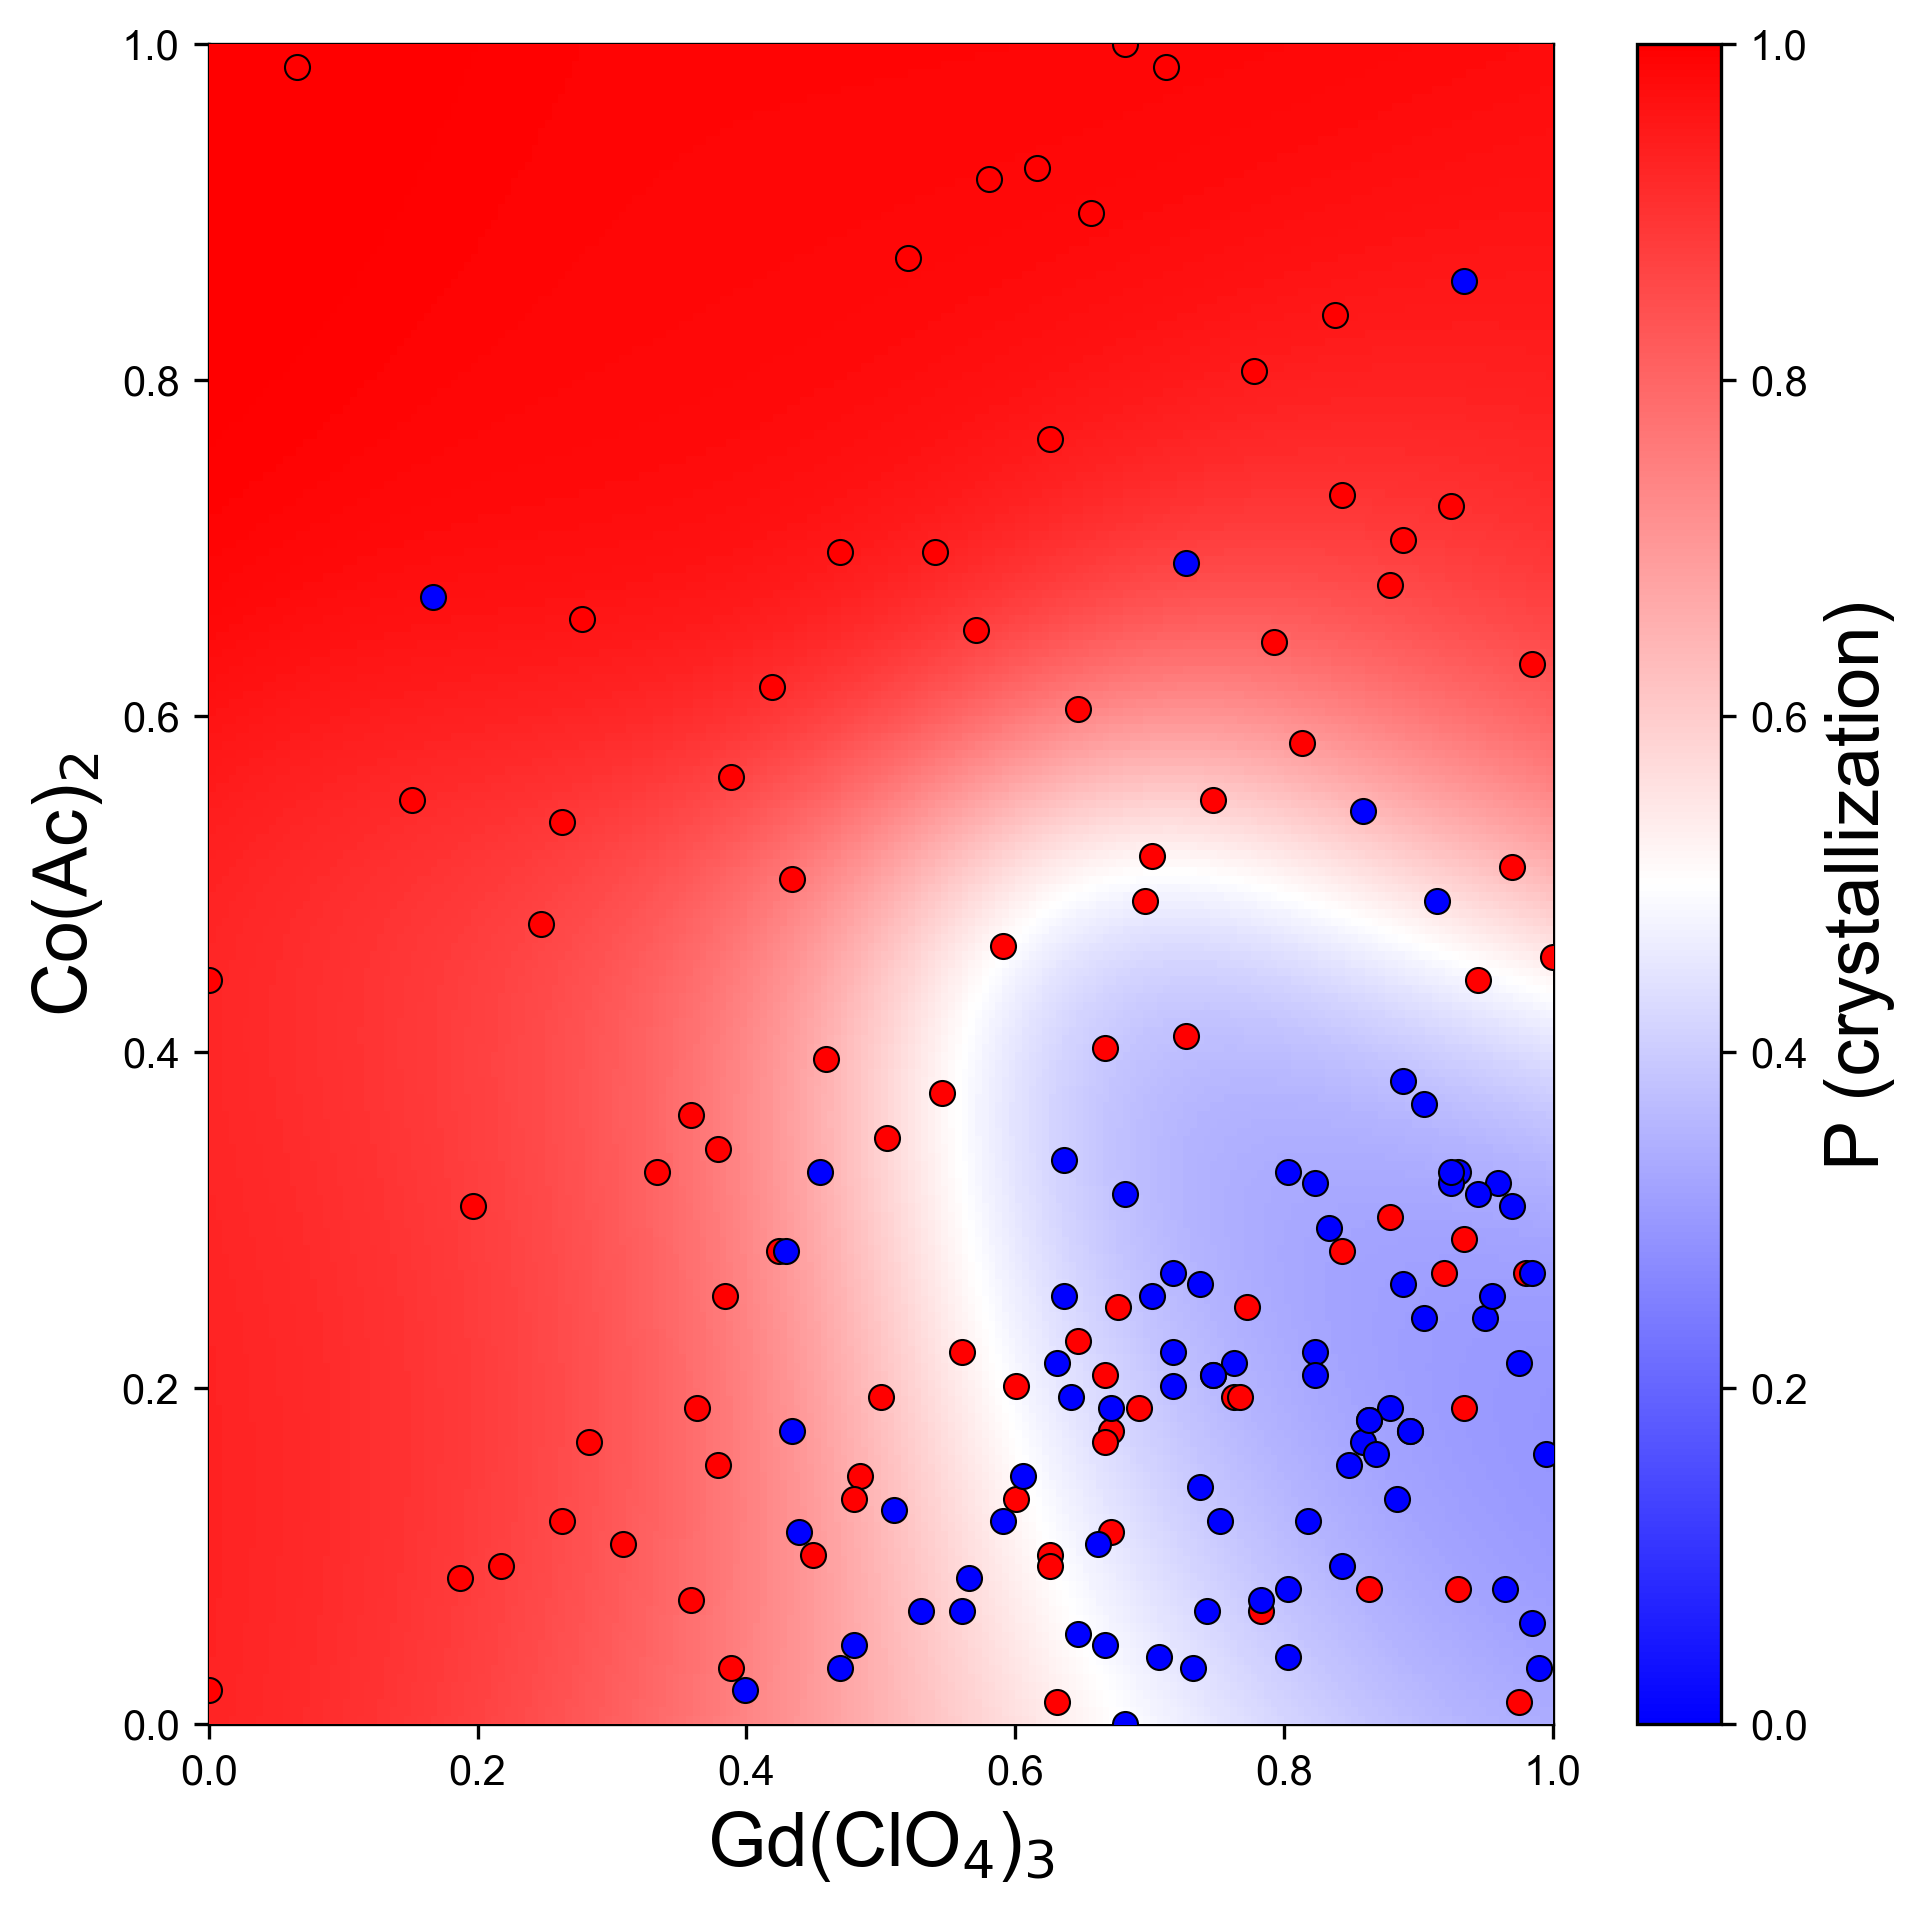

In [14]:
from plot_tools import plot_phase_diagram, create_prediction_grid
dimension_index = [0, 1]  # 选择要绘制的两个自由维度索引
X_grid, grid_shape = create_prediction_grid(
    fixed_dims=[2, 3], #选择固定的特征索引
    fixed_vals=[0.5, 0.5], #固定特征的值（选定切片位置）
    resolution=200  # 200^2 = 40000个点
)
feature_names = [r'Gd(ClO$_4$)$_3$', r'Co(Ac)$_2$', "NaAc", "NaOH"]
plot_phase_diagram(LS_model2, X_grid, grid_shape, norm_X2, Y2, dimension_index, feature_names)